# THE FINDER ANALYSIS OF S. AUREUS STRAINS

In [2]:
#install.packages("readr")
.libPaths(c("~/R/x86_64-pc-linux-gnu-library/4.1", .libPaths()))



In [40]:
library(readr)
library(dplyr)
library(stringr)
library(ggplot2)
library(tibble)
library(purrr)
library(ggrepel)
library(pheatmap)
library(tidyr)
library(forcats)
library(patchwork)
library(RColorBrewer)

## OUR DATA - TANZANIA

#### 1. METADATA

In [4]:
# metadata check

metadata <- read_tsv("../../results_for_analysis/metadata/s_aureus_metadata.tsv", show_col_types = FALSE) |> 
    rename(
        sample = `Sequence file name`,
        date        = `Date of isolation`,
        sample_type = `Sample type`,
        host        = `Sample source`,
        region      = Region,
        animal_contact = `Human Contact with animals`,
        species     = Species,
        ST_meta     = ST
    )

# metadata overview

count(metadata, host)
count(metadata, region)
count(metadata, host, region) |>
    pivot_wider(names_from = region, values_from = n, values_fill = 0)

count(metadata, ST_meta, sort = TRUE)
count(metadata, sample_type, host)


metadata |>
     filter(host == "Human") |>
     count(animal_contact)




host,n
<chr>,<int>
Cow,43
Human,19


region,n
<chr>,<int>
Bagamoyo,26
D’Salaam,12
Morogoro,14
Tanga,10


host,Bagamoyo,Morogoro,Tanga,D’Salaam
<chr>,<int>,<int>,<int>,<int>
Cow,21,13,9,0
Human,5,1,1,12


ST_meta,n
<chr>,<int>
ST7846,12
ST152,11
ST97,9
ST5477,7
ST121,4
ST7841,4
ST7840,3
Unkown,3
ST7845,2


sample_type,host,n
<chr>,<chr>,<int>
Milk,Cow,43
Nasal swab,Human,19


animal_contact,n
<chr>,<int>
No,12
Yes,7


#### 2. QC PASSED ASSEMBLIES

In [5]:
passed_samples <- read_lines("../../results_for_analysis/metadata/sample_list_QC_passed.txt")

#### 3. KMERFINDER - quick species check

how was kmerfinder ran??

In [6]:
species_df_best5 <- read_tsv("../../results_for_analysis/kmerfinder/kmerfinder_for_trimmed_reads/kmerfinder_summary.txt") # nolint
species_df_best5 |> filter(Sample == "R0051_BC00101") 
species_df_best5 |> filter(Sample == "Q0003_BC00406")


Rows: 236 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (6): Sample, # Sequence ID, Accession Number, Description, Taxonomy, Sp...
dbl (14): Num, Score, Expected, Template_length, Query_Coverage, Template_Co...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Sample,# Sequence ID,Num,Score,Expected,Template_length,Query_Coverage,Template_Coverage,Depth,tot_query_Coverage,tot_template_Coverage,tot_depth,q_value,p_value,Accession Number,Description,TAXID,Taxonomy,TAXID Species,Species
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>
R0051_BC00101,GCF_013307005.1,3154,35823,8,1979,0.66,1.59,18.10,2.77,14.98,75.86,35798.42,1e-26,NZ_CP053354.1,"Staphylococcus aureus strain 16405 chromosome, complete genome",1280,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus aureus,1280,Staphylococcus aureus
R0051_BC00101,GCF_003186125.1,14482,44143,1048,122698,0.81,1.50,0.36,48.64,91.66,21.50,41095.08,1e-26,NZ_CP029627.1,"Staphylococcus aureus strain MOK042 chromosome, complete genome",1280,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus aureus,1280,Staphylococcus aureus
R0051_BC00101,GCF_015767495.1,23433,157340,1025,122865,2.90,1.01,1.28,39.46,68.50,17.41,154290.72,1e-26,NZ_CP065194.1,"Staphylococcus aureus strain GDC6P096P chromosome, complete genome",1280,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus aureus,1280,Staphylococcus aureus
R0051_BC00101,GCF_906464895.1,1229,210637,0,71,3.88,56.72,2966.72,3.88,56.72,2966.72,210635.32,1e-26,NZ_OD940427.1,Enterococcus faecalis isolate WE0851 chromosome contig000006,1351,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Lactobacillales; Enterococcaceae; Enterococcus; Enterococcus faecalis,1351,Enterococcus faecalis
R0051_BC00101,GCF_900474755.1,23310,2965525,372,122530,54.69,95.73,24.20,54.69,95.73,24.20,2964408.48,1e-26,NZ_LS483324.1,"Staphylococcus aureus strain NCTC10344 genome assembly, chromosome: 1",1280,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus aureus,1280,Staphylococcus aureus


Sample,# Sequence ID,Num,Score,Expected,Template_length,Query_Coverage,Template_Coverage,Depth,tot_query_Coverage,tot_template_Coverage,tot_depth,q_value,p_value,Accession Number,Description,TAXID,Taxonomy,TAXID Species,Species
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>
Q0003_BC00406,GCF_906464895.1,1229,33,2,71,0.00,10.45,0.46,0.00,10.45,0.46,25.31,4.9e-07,NZ_OD940427.1,Enterococcus faecalis isolate WE0851 chromosome contig000006,1351,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Lactobacillales; Enterococcaceae; Enterococcus; Enterococcus faecalis,1351,Enterococcus faecalis
Q0003_BC00406,GCF_013307005.1,3154,60641,40,1979,0.20,1.91,30.64,4.00,13.28,615.72,60520.51,1.0e-26,NZ_CP053354.1,"Staphylococcus aureus strain 16405 chromosome, complete genome",1280,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus aureus,1280,Staphylococcus aureus
Q0003_BC00406,GCF_900635285.1,1127,1280077,4862,122530,4.20,8.93,10.45,31.36,95.36,78.05,1265561.74,1.0e-26,NZ_LR134087.1,"Staphylococcus aureus strain NCTC7121 genome assembly, chromosome: 1",1280,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus aureus,1280,Staphylococcus aureus
Q0003_BC00406,GCF_009728755.1,9859,2260791,4693,125302,7.41,4.81,18.04,28.04,68.37,68.25,2246749.12,1.0e-26,NZ_CP033112.1,"Staphylococcus aureus strain ST20130944 chromosome, complete genome",1280,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus aureus,1280,Staphylococcus aureus
Q0003_BC00406,GCF_013836745.1,17813,10962020,2627,123919,35.94,83.28,88.46,35.94,83.28,88.46,10954140.72,1.0e-26,NZ_CP058613.1,"Staphylococcus aureus strain 128254 chromosome, complete genome",1280,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus aureus,1280,Staphylococcus aureus


In [7]:
# show any non-S.aureus hits with substantial coverage
species_df_best5 |> 
  filter(Species != "Staphylococcus aureus", Template_Coverage >= 20 | Query_Coverage >= 20,
        Template_length >= 100) |> 
  arrange(desc(Template_Coverage), desc(Query_Coverage))

# per-sample summary: S.aureus coverage vs max other-species coverage
species_df_best5 |> 
  group_by(Sample) |> 
  filter(Template_length >= 100) |>
  summarise(
    sa_template = max(Template_Coverage[Species == "Staphylococcus aureus"], na.rm = TRUE),
    max_other   = max(Template_Coverage[Species != "Staphylococcus aureus"], na.rm = TRUE)
  ) |> 
  filter(max_other != -Inf) |>
  arrange(desc(max_other)) 

Sample,# Sequence ID,Num,Score,Expected,Template_length,Query_Coverage,Template_Coverage,Depth,tot_query_Coverage,tot_template_Coverage,tot_depth,q_value,p_value,Accession Number,Description,TAXID,Taxonomy,TAXID Species,Species
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>
R0047_DADST030,GCF_014334295.1,15068,282986,471,103657,10.11,72.30,2.73,12.00,74.04,3.24,281574.3,1e-26,NZ_CP060528.1,"Staphylococcus epidermidis strain LM087 chromosome, complete genome",1282,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus epidermidis,1282,Staphylococcus epidermidis
R0051_DADST045,GCF_014334295.1,15068,151195,878,103657,3.17,55.24,1.46,4.91,58.15,2.26,148580.6,1e-26,NZ_CP060528.1,"Staphylococcus epidermidis strain LM087 chromosome, complete genome",1282,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus epidermidis,1282,Staphylococcus epidermidis
R0052_DADST091,GCF_005706435.1,19853,105687,306,109253,6.43,36.91,0.97,7.73,39.01,1.16,104770.6,1e-26,NZ_CP035541.1,"Staphylococcus haemolyticus strain PK-01 chromosome, complete genome",1283,cellular organisms; Bacteria; Terrabacteria group; Firmicutes; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus haemolyticus,1283,Staphylococcus haemolyticus


Warning message:
“There were 49 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_other = max(Template_Coverage[Species != "Staphylococcus
  aureus"], na.rm = TRUE)`.
ℹ In group 3: `Sample = "Q0003_BC00105"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 48 remaining warnings.”


Sample,sa_template,max_other
<chr>,<dbl>,<dbl>
R0047_DADST030,97.34,72.30
R0051_DADST045,98.89,55.24
R0052_DADST091,56.48,36.91
R0047_DABST013,98.86,18.68
R0051_TC00219,83.88,6.31
Q0003_TC00512,82.66,2.27
Q0003_MC00214,97.95,1.96
Q0003_BC00102,83.07,1.79
R0047_TH0405,98.83,1.69


In [8]:
# diagnostic flagging
species_df_best5 |>
  group_by(Sample) |>
  summarise(
    sa_q      = max(Query_Coverage[Species == "Staphylococcus aureus"], na.rm = TRUE),
    sa_t      = max(Template_Coverage[Species == "Staphylococcus aureus"], na.rm = TRUE),
    other_q   = max(Query_Coverage[Species != "Staphylococcus aureus"], na.rm = TRUE),
    other_t   = max(Template_Coverage[Species != "Staphylococcus aureus"], na.rm = TRUE),
    other_len = max(Template_length[Species != "Staphylococcus aureus"], na.rm = TRUE)
  ) |>
  replace_na(list(sa_q = 0, sa_t = 0, other_q = 0, other_t = 0, other_len = 0)) |>
  filter(
    other_q >= 60 |
    other_t >= 70 |
    other_len >= 250 |
    other_t >= 0.8 * sa_t
  ) |>
  arrange(desc(other_t), desc(other_q))

Warning message:
“There were 105 warnings in `summarise()`.
The first warning was:
ℹ In argument: `other_q = max(Query_Coverage[Species != "Staphylococcus
  aureus"], na.rm = TRUE)`.
ℹ In group 3: `Sample = "Q0003_BC00105"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 104 remaining warnings.”


Sample,sa_q,sa_t,other_q,other_t,other_len
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
R0047_DADST030,80.30,97.34,10.11,72.30,112170
R0051_DADST045,87.09,98.89,3.48,55.24,109253
R0051_TC00219,81.33,83.88,2.10,43.28,122575
R0052_DADST091,61.13,56.48,6.43,36.91,112564
R0047_DABST013,85.64,98.86,1.29,18.68,107000
Q0003_TC00512,79.46,82.66,2.21,2.27,122569
Q0003_MC00214,93.05,97.95,0.09,1.96,116470
Q0003_BC00102,70.56,83.07,1.13,1.79,122575
R0047_TH0405,89.29,98.83,0.12,1.69,113236


Rows: 62 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (6): Sample, # Sequence ID, Accession Number, Description, Taxonomy, Sp...
dbl (14): Num, Score, Expected, Template_length, Query_Coverage, Template_Co...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Sample"                "# Sequence ID"         "Num"                  
 [4] "Score"                 "Expected"              "Template_length"      
 [7] "Query_Coverage"        "Template_Coverage"     "Depth"                
[10] "tot_query_Coverage"    "tot_template_Coverage" "tot_depth"            
[13] "q_value"               "p_value"               "Accession Number"     
[16] "Description"           "TAXID"                 "Taxonomy"             
[19] "TAXID Species"         "Species"

Total isolates: 53 
Passed QC:      51 
Flagged:        2 

# A tibble: 2 × 4
  sample        query_cov template_cov depth
  <chr>             <dbl>        <dbl> <dbl>
1 R0051_BC00101      54.7         95.7  24.2
2 Q0003_BC00406      35.9         83.3  88.5


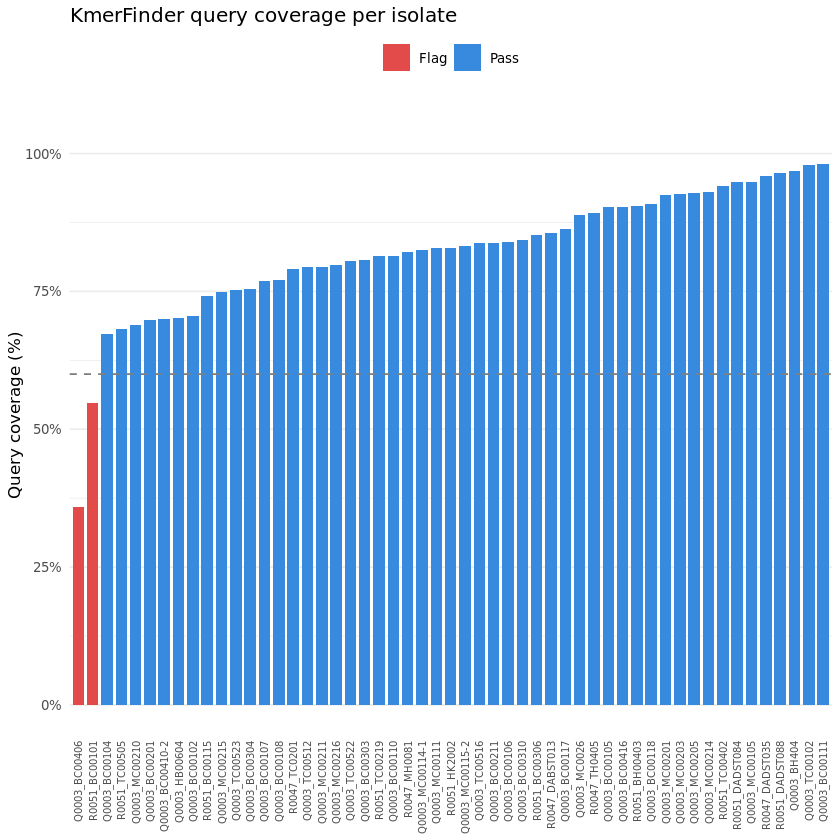

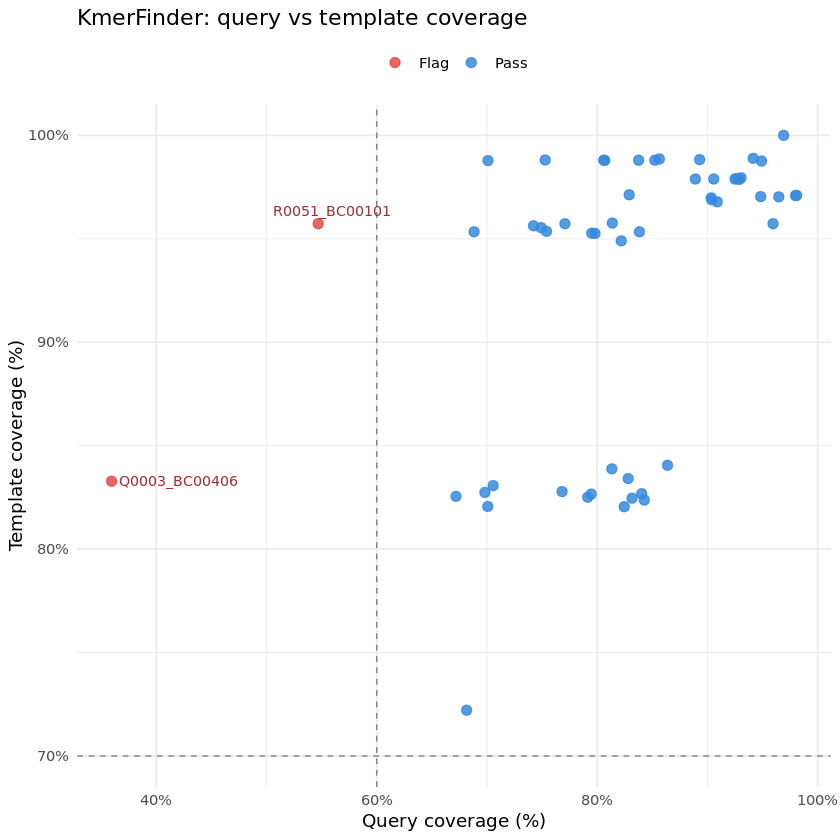

In [9]:
species_df <- read_tsv("../../results_for_analysis/kmerfinder/kmerfinder_for_trimmed_reads/kmerfinder_summary_1st_hit.txt")

# kmer - rapid species confirmation
colnames(species_df)
#species_df |> filter(Species != "Staphylococcus aureus")

species_df <- species_df |>
    filter(Sample %in% passed_samples)


# QC thresholds
QC_QUERY_COV  <- 60   # minimum query coverage %
QC_TEMPL_COV  <- 70   # minimum template coverage %

species_df <- species_df |>
  rename(
    sample          = Sample,
    query_cov       = Query_Coverage,
    template_cov    = Template_Coverage,
    depth           = Depth,
    description     = Description
  ) |>
  mutate(
    qc_pass = query_cov >= QC_QUERY_COV & template_cov >= QC_TEMPL_COV,
    label   = if_else(qc_pass, "Pass", "Flag")
  )

# summary
cat("Total isolates:", nrow(species_df), "\n")
cat("Passed QC:     ", sum(species_df$qc_pass), "\n")
cat("Flagged:       ", sum(!species_df$qc_pass), "\n\n")
print(species_df |> filter(!qc_pass) |> select(sample, query_cov, template_cov, depth))

# plot 1:
p1 <- species_df |>
  arrange(query_cov) |>
  mutate(sample = factor(sample, levels = sample)) |>
  ggplot(aes(x = sample, y = query_cov, fill = label)) +
  geom_col(width = 0.8) +
  geom_hline(yintercept = QC_QUERY_COV, linetype = "dashed", colour = "grey50", linewidth = 0.5) +
  scale_fill_manual(values = c("Pass" = "#378ADD", "Flag" = "#E24B4A")) +
  scale_y_continuous(limits = c(0, 105), labels = function(x) paste0(x, "%")) +
  labs(x = NULL, y = "Query coverage (%)",
       title = "KmerFinder query coverage per isolate",
       fill = NULL) +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
        legend.position = "top",
        panel.grid.major.x = element_blank())



# plot 2
p2 <- species_df |>
  ggplot(aes(x = query_cov, y = template_cov, colour = label, label = sample)) +
  geom_point(size = 2.5, alpha = 0.85) +
  geom_vline(xintercept = QC_QUERY_COV, linetype = "dashed", colour = "grey50", linewidth = 0.4) +
  geom_hline(yintercept = QC_TEMPL_COV, linetype = "dashed", colour = "grey50", linewidth = 0.4) +
  ggrepel::geom_text_repel(data = filter(species_df, !qc_pass),
                            size = 3, colour = "#A32D2D", max.overlaps = 10) +
  scale_colour_manual(values = c("Pass" = "#378ADD", "Flag" = "#E24B4A")) +
  scale_x_continuous(labels = function(x) paste0(x, "%")) +
  scale_y_continuous(labels = function(x) paste0(x, "%")) +
  labs(x = "Query coverage (%)", y = "Template coverage (%)",
       title = "KmerFinder: query vs template coverage",
       colour = NULL) +
  theme_minimal(base_size = 11) +
  theme(legend.position = "top")



p1
p2

#### 4. MLST RESULTS

In [10]:
# mlst typing 

mlst_df <- read_tsv("../../results_for_analysis/mlst/mlst_summary.txt", col_names = FALSE, show_col_types = FALSE)
colnames(mlst_df) <- c("sample", "species", "ST", "gene1", "gene2", "gene3", "gene4", "gene5", "gene6", "gene7")

mlst_df <- mlst_df |>
    mutate(sample = sample |>
        str_remove("^/home/projects/course_23262/group/group1/23262_infectious_disease_project/data/assemblies_QC_passed/") %>%
        str_remove("\\.fasta$")) |>
        filter(sample %in% passed_samples)

mlst_df |> count(ST, sort=TRUE)

ST,n
<chr>,<int>
7846,12
97,9
152,8
5477,6
7841,4
7840,3
121,2
7845,2
-,1


In [11]:
# compare metadata and mlst results

meta_vs_mlst <- metadata |>
  left_join(mlst_df |> select(sample, ST_mlst = ST), by = "sample") |>
  mutate(
    # normalise metadata ST: strip "ST" prefix, fix typos
    ST_meta_clean = str_remove(ST_meta, "^ST") |> str_trim(),
    ST_meta_clean = case_when(
      ST_meta_clean == "Unknown" ~ NA_character_,
      ST_meta_clean == "Unkown"  ~ NA_character_,   # typo in metadata
      TRUE                       ~ ST_meta_clean
    ),
    ST_mlst_clean = as.character(ST_mlst),
    # agreement check
    ST_match = case_when(
      is.na(ST_meta_clean)  ~ "meta_unknown",
      is.na(ST_mlst_clean)  ~ "mlst_missing",
      ST_mlst_clean == "-" ~ "mlst_missing",
      is.na(ST_meta_clean) & is.na(ST_mlst_clean) ~ "both_missing",
      ST_meta_clean == ST_mlst_clean ~ "match",
      TRUE                           ~ "mismatch"
    )
  )

#inspect
count(meta_vs_mlst, ST_match)

meta_vs_mlst |>
  filter(ST_match == "mismatch") |>
  select(sample, ST_meta, ST_mlst, host, region)

# remove samples that didnt pass qc at assembly
# because i only ran resfinder with qc passed assemblies_QC_passed
meta_vs_mlst <- meta_vs_mlst |>
  filter(sample %in% passed_samples)

print("Inspection after filtering:")
#inspect again after filtering
count(meta_vs_mlst, ST_match)

meta_vs_mlst |>
  filter(ST_match == "mismatch") |>
  select(sample, ST_meta, ST_mlst, host, region)

# WELL THIS IS GOOD NEWS

ST_match,n
<chr>,<int>
match,52
meta_unknown,4
mlst_missing,6


sample,ST_meta,ST_mlst,host,region
<chr>,<chr>,<chr>,<chr>,<chr>


[1] "Inspection after filtering:"


ST_match,n
<chr>,<int>
match,52
mlst_missing,1


sample,ST_meta,ST_mlst,host,region
<chr>,<chr>,<chr>,<chr>,<chr>


Here I checked the agreement between metadata and our mlst results.
Most are okay, and one is missing in mlst.
Good news!! The one missing in MLST can be either taken from metadata or left empty. Doesn't really matter I think
 

In [12]:
colnames(meta_vs_mlst)

[1] "sample"             "date"               "sample_type"       
 [4] "host"               "region"             "animal_contact"    
 [7] "species"            "ST_meta"            "Sequencing machine"
[10] "ST_mlst"            "ST_meta_clean"      "ST_mlst_clean"     
[13] "ST_match"

In [13]:
# resolve with mlst priority
final_strain_data <- meta_vs_mlst |>
    mutate(ST_final = case_when(
      ST_mlst_clean != "-"  ~ ST_mlst_clean,   # trust MLST first
      !is.na(ST_meta_clean)  ~ ST_meta_clean
     )) |> 
     select(-c(ST_meta, ST_meta_clean, ST_mlst_clean, ST_match, `Sequencing machine`))

count(final_strain_data, ST_final, sort = TRUE)


ST_final,n
<chr>,<int>
7846,12
97,9
152,8
5477,7
7841,4
7840,3
121,2
7845,2
22,1


In [ ]:
metadata_tidy <- final_strain_data |>
    select(-ST_mlst) |>
    rename(ST = ST_final)

write_tsv(metadata_tidy, "../../results_for_analysis/metadata/metadata_tidy_tanzania.tsv")

In [ ]:
# plots


# load data 
metadata_tidydata_tidy <- read_tsv("../../results_for_analysis/metadata_tidydata/metadata_tidydata_tidy_tanzania.tsv")


# colour palettes
# ST colours — ST152 always yellow 
all_sts <- sort(unique(as.character(metadata_tidy$ST)))
st_pal <- setNames(
  colorRampPalette(brewer.pal(12, "Paired"))(length(all_sts)),
  all_sts
)
st_pal["152"] <- "#eeff01"

host_pal   <- c("Cow"   = "#6BAED6", "Human" = "#FD8D3C")
region_pal <- c(
  "Bagamoyo" = "#B3CDE3",
  "Morogoro" = "#8C96C6",
  "Tanga"    = "#88419D",
  "D'Salaam" = "#2D004B"
)

#  ST distribution 
# Count per ST, ordered by frequency descending
st_counts <- metadata_tidy |>
  mutate(ST = factor(as.character(ST))) |>
  count(ST, host, region) |>
  group_by(ST) |>
  mutate(total = sum(n)) |>
  ungroup() |>
  mutate(ST = fct_reorder(ST, -total))

# 1a. Main bar: total count per ST, filled by host
p1 <- ggplot(st_counts, aes(x = ST, y = n, fill = host)) +
  geom_col(color = "white", linewidth = 0.3) +
  # Highlight ST152 bar with a yellow outline
  geom_col(
    data = st_counts |> filter(ST == "152"),
    aes(x = ST, y = n, fill = host),
    color = "#eeff01", linewidth = 1.2
  ) +
  # Total count label on top of each bar
  geom_text(
    data = st_counts |> group_by(ST) |> summarise(total = sum(n)),
    aes(x = ST, y = total, label = total, fill = NULL),
    vjust = -0.5, size = 3.5, fontface = "bold", color = "grey30"
  ) +
  scale_fill_manual(values = host_pal, name = "Host") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.12))) +
  labs(
    title    = "Sequence type distribution — S. aureus Tanzania (n=53)",
    subtitle = "ST152 highlighted; bars split by host",
    x        = "Sequence type (ST)",
    y        = "Number of isolates"
  ) +
  theme_classic(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(color = "grey40", size = 11),
    axis.text.x   = element_text(angle = 45, hjust = 1),
    legend.position = "top"
  )

# 1b. Region breakdown beneath — small dot plot showing which regions each ST appears in
region_counts <- metadata_tidy |>
  mutate(ST = fct_reorder(factor(as.character(ST)),
                           -as.integer(factor(as.character(ST),
                                              levels = levels(st_counts$ST))))) |>
  count(ST, region) |>
  mutate(ST = factor(ST, levels = levels(st_counts$ST)))

p1_region <- ggplot(region_counts, aes(x = ST, y = n, fill = region)) +
  geom_col(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = region_pal, name = "Region") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  labs(x = NULL, y = "n (region)") +
  theme_classic(base_size = 11) +
  theme(
    axis.text.x     = element_blank(),
    axis.ticks.x    = element_blank(),
    legend.position = "top"
  )

# Combine with patchwork: region strip above, main bar below
fig1 <- p1_region / p1 +
  plot_layout(heights = c(1, 3))

fig1


#ggsave("st_distribution.png", fig1,
 #      width = 12, height = 8, dpi = 300, bg = "white")



# ST152 breakdown
st152 <- metadata_tidy |> filter(ST == 152)

# Check what we have
cat("\nST152 isolates (n =", nrow(st152), "):\n")
print(st152 |> select(sample, host, region, sample_type))

# 2a. Host breakdown
st152_host <- st152 |> count(host)

p2a <- ggplot(st152_host, aes(x = host, y = n, fill = host)) +
  geom_col(color = "white", linewidth = 0.5, width = 0.6) +
  geom_text(aes(label = n), vjust = -0.5, size = 5, fontface = "bold") +
  scale_fill_manual(values = host_pal) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.2)), limits = c(0, NA)) +
  labs(x = "Host", y = "Number of isolates", title = "Host") +
  theme_classic(base_size = 13) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5))

# 2b. Region breakdown
st152_region <- st152 |> count(region)

p2b <- ggplot(st152_region, aes(x = fct_reorder(region, -n), y = n, fill = region)) +
  geom_col(color = "white", linewidth = 0.5, width = 0.6) +
  geom_text(aes(label = n), vjust = -0.5, size = 5, fontface = "bold") +
  scale_fill_manual(values = region_pal) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.2)), limits = c(0, NA)) +
  labs(x = "Region", y = NULL, title = "Region") +
  theme_classic(base_size = 13) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5))

# 2c. Sample type breakdown
st152_type <- st152 |> count(sample_type)

p2c <- ggplot(st152_type, aes(x = fct_reorder(sample_type, -n), y = n,
                               fill = sample_type)) +
  geom_col(color = "white", linewidth = 0.5, width = 0.6) +
  geom_text(aes(label = n), vjust = -0.5, size = 5, fontface = "bold") +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.2)), limits = c(0, NA)) +
  labs(x = "Sample type", y = NULL, title = "Sample type") +
  theme_classic(base_size = 13) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5))

# Combine the three panels
fig2 <- p2a + p2b + p2c +
  plot_annotation(
    title    = "ST152 — isolate characteristics (n=8)",
    subtitle = "Distributed across hosts, regions, and sample types",
    theme    = theme(
      plot.title    = element_text(face = "bold", size = 15),
      plot.subtitle = element_text(color = "grey40", size = 12)
    )
  )

ggsave("st152_breakdown.png", fig2,
       width = 10, height = 5, dpi = 300, bg = "white")

cat("Saved: st152_breakdown.png\n")

# ── Quick summary printed to console ─────────────────────────────────────────
cat("\n── ST summary ───────────────────────────────\n")
metadata_tidy |>
  count(ST, host) |>
  pivot_wider(names_from = host, values_from = n, values_fill = 0) |>
  mutate(Total = rowSums(across(where(is.numeric)))) |>
  arrange(desc(Total)) |>
  print()

We end up with 8 ST152 !!

#### 5. RESFINDER 

In [16]:
#load data
pheno <- read_tsv("../../results_for_analysis/resfinder/our_data/all_pheno_table.tsv", show_col_types = FALSE)
resfinder_df <- read_tsv("../../results_for_analysis/resfinder/our_data/all_resfinder_tab.tsv", show_col_types = FALSE)

colnames(resfinder_df)


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


[1] "Sample"                       "Resistance gene"             
 [3] "Identity"                     "Alignment Length/Gene Length"
 [5] "Coverage"                     "Position in reference"       
 [7] "Contig"                       "Position in contig"          
 [9] "Phenotype"                    "Accession no."

In [17]:
resfinder_filtered <- resfinder_df |> 
    select(c(Sample, `Resistance gene`, Phenotype, Identity, Coverage)) |>
    rename(
        sample = Sample,
        gene = `Resistance gene`,
        phenotype = Phenotype,
        coverage = Coverage,
        identity = Identity
    ) |>
    # remove duplicated genes per sample
    distinct()

# add back samples with no resistance genes
resfinder_filtered <- tibble(sample = passed_samples) |>
    left_join(resfinder_filtered, by = "sample")


In [18]:
# presence / absence matrix for the gene heatmap

pa_mat <- resfinder_filtered |>
    filter(!is.na(gene)) |>
    mutate(present = 1L) |>
    pivot_wider(id_cols = sample, names_from = gene,
                values_from = present, values_fill = 0L)

# add back samples with no genes
missing_samples <- setdiff(passed_samples, pa_mat$sample)

pa_mat <- pa_mat |>
    bind_rows(tibble(sample = missing_samples)) |>
    mutate(across(where(is.numeric), ~replace_na(.x, 0))) |>
    column_to_rownames("sample") |>
    as.matrix()



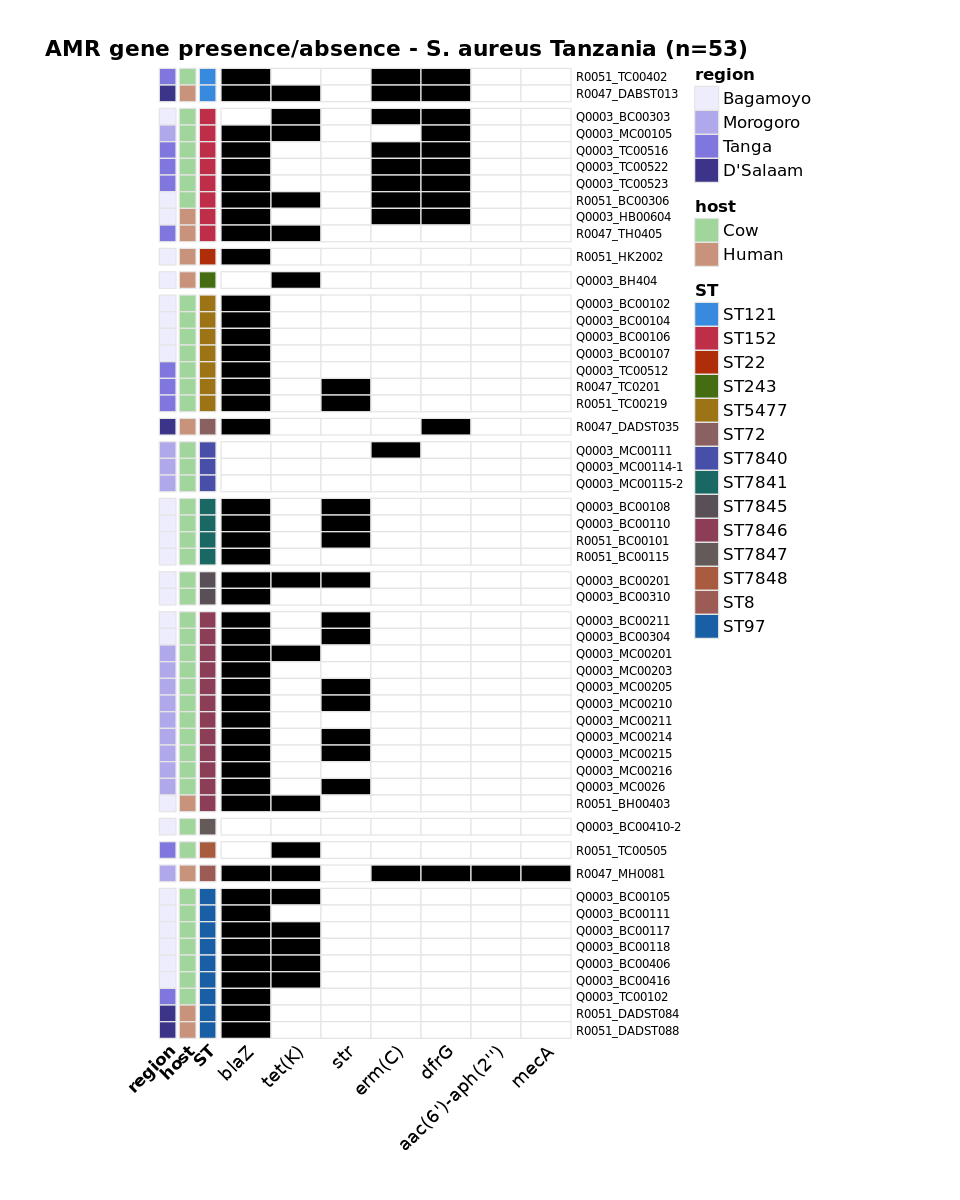

In [19]:
# build annotation

annot_row <- final_strain_data |>
    mutate(
      ST = paste0("ST", ST_final),
      region = iconv(region, from = "UTF-8", to = "ASCII//TRANSLIT") #idk encoding is a bitch
    ) |>
    select(sample, ST, host, region) |>
    arrange(ST, host) |>
    column_to_rownames("sample")



# match matrix row order to annotation
pa_mat <- pa_mat[rownames(annot_row), , drop=FALSE]
pa_mat_our <- pa_mat

# create gaps between ST groups
gap_pos <- annot_row |>
  mutate(row_n = row_number()) |>
  group_by(ST) |>
  summarise(last = max(row_n), .groups = "drop") |>
  arrange(last) |>
  pull(last) |>
  head(-1)


# colors for heatmap

st_levels <- unique(annot_row$ST) |> sort()
st_cols <- setNames(
  colorRampPalette(c("#378ADD","#fa0606","#3B6D11","#BA7517",
                     "#534AB7","#0F6E56","#993556","#5F5E5A",
                     "#D85A30","#185FA5"))(length(st_levels)),
  st_levels
)

ann_colors <- list(
  ST = st_cols,
  host = c(
    "Cow" = "#a0d69c",    # choose any hex
    "Human" = "#c9937b"
  ),
  region = c(
    "Bagamoyo" = "#EEEDFE",
    "Morogoro" = "#AFA9EC",
    "Tanga" = "#7F77DD",
    "D\'Salaam" = "#3C3489"
  )
)
# heatmap. finally omg

options(repr.plot.width = 8, repr.plot.height = 10)


pheatmap(
  pa_mat,
  annotation_row    = annot_row,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = FALSE,
  gaps_row          = gap_pos,
  color             = c("white", "black"),
  breaks            = c(-0.5, 0.5, 1.5),
  border_color      = "grey90",
  cellwidth         = 30,
  cellheight        = 10,
  fontsize_row      = 7,
  fontsize_col      = 11,
  angle_col         = 45,
  legend            = FALSE,
  main              = "AMR gene presence/absence - S. aureus Tanzania (n=53)",
  #          = "results/resfinder_heatmap.pdf",
  width             = 14,
  height            = 18
)

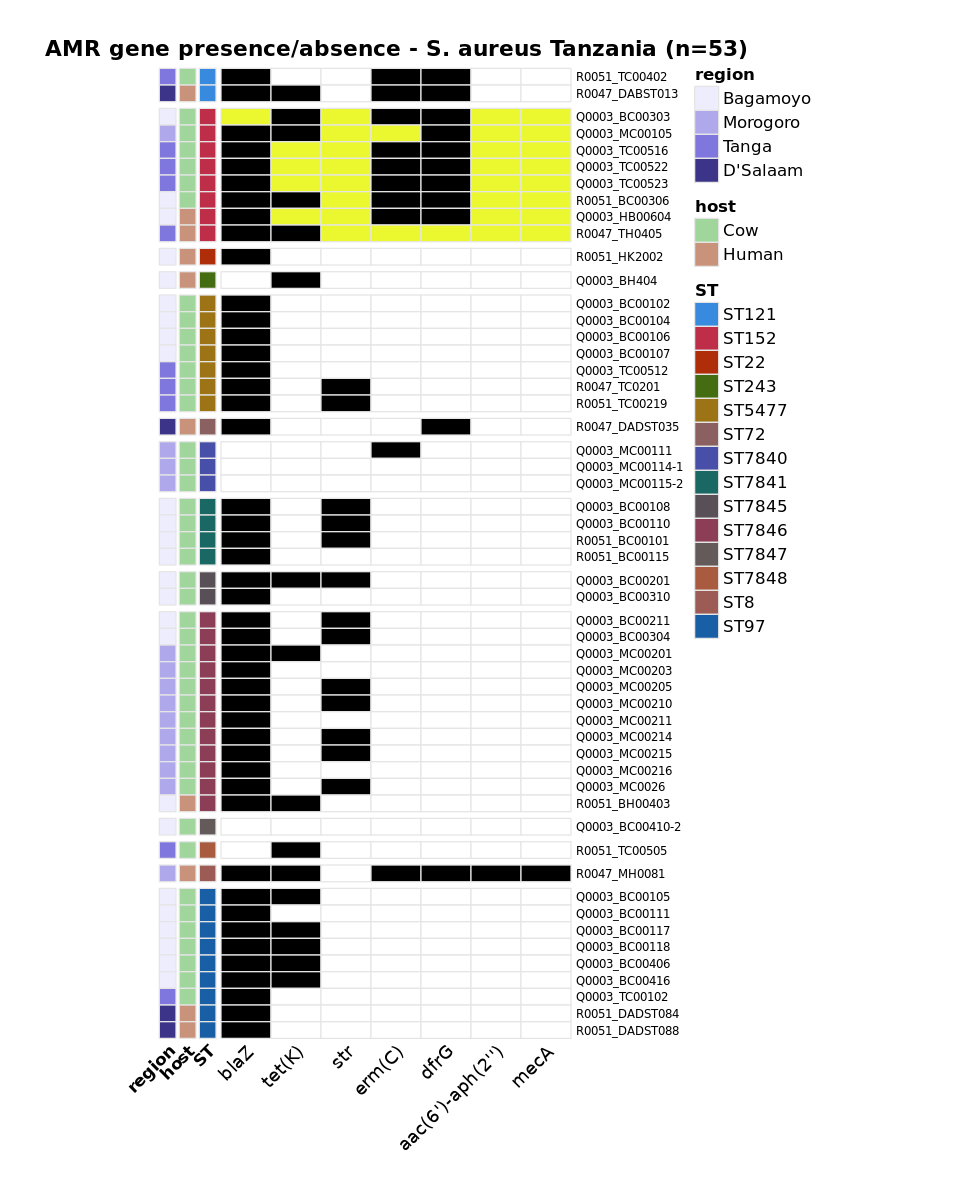

In [20]:

# make ST152 emoty cells light yellow
pa_plot <- pa_mat
st152_rows <- rownames(annot_row)[annot_row$ST == "ST152"]

tmp <- pa_plot[st152_rows, , drop = FALSE]
tmp[tmp == 0] <- -1
pa_plot[st152_rows, ] <- tmp

pheatmap(
  pa_plot,
  annotation_row    = annot_row,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = FALSE,
  gaps_row          = gap_pos,
  color             = c("#ebf830", "white", "black"),  # ST152-0, other-0, 1
  breaks            = c(-1.5, -0.5, 0.5, 1.5),
  border_color      = "grey90",
  cellwidth         = 30,
  cellheight        = 10,
  fontsize_row      = 7,
  fontsize_col      = 11,
  angle_col         = 45,
  legend            = FALSE,
  main              = "AMR gene presence/absence - S. aureus Tanzania (n=53)"
)


We can already see this strain is more resistant!!!!

## AUGMENTED DATA FROM MLSTPUB

#### 

In [21]:
resfinder_aug <- read_tsv("../../results_for_analysis/resfinder/aug_data/all_resfinder_tab.tsv", show_col_types = FALSE)
passed_samples_aug <- read_tsv("../../results_for_analysis/metadata/sample_list_augm_postQC.txt", col_names = FALSE) 

head(resfinder_aug)
head(passed_samples_aug)

Rows: 112 Columns: 1
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): X1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Sample,Resistance gene,Identity,Alignment Length/Gene Length,Coverage,Position in reference,Contig,Position in contig,Phenotype,Accession no.
<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
ST121_id24328_ERR505363.fasta,blaZ,100,846/846,100.00000,1..846,ERR505363_A130980_NODE_27_COV_59.977810,6658..7503,"Amoxicillin, Ampicillin, Penicillin, Piperacillin",AP004832
ST121_id24328_ERR505363.fasta,dfrG,100,498/498,100.00000,1..498,ERR505363_A130980_NODE_29_COV_18.282499,53332..53829,Trimethoprim,AB205645
ST121_id24971_ERR505373.fasta,blaZ,100,888/888,100.00000,1..888,ERR505373_A131753_NODE_4_COV_24.781187,9189..10076,"Amoxicillin, Ampicillin, Penicillin, Piperacillin",CP003979
ST121_id24971_ERR505373.fasta,erm(C),100,735/735,100.00000,1..735,ERR505373_A131753_NODE_20_COV_278.088959,396..1130,"Erythromycin, Lincomycin, Clindamycin, Quinupristin, Pristinamycin IA, Virginiamycin S",M13761
ST121_id24971_ERR505373.fasta,tet(K),100,1112/1380,80.57971,269..1380,ERR505373_A131753_NODE_111_COV_259.767303,1..1112,"Doxycycline, Tetracycline",U38656
ST121_id24971_ERR505373.fasta,tet(K),100,352/1380,25.50725,1..352,ERR505373_A131753_NODE_111_COV_259.767303,4172..4523,"Doxycycline, Tetracycline",U38656


X1
<chr>
ST121_id24328_ERR505363
ST121_id24971_ERR505373
ST121_id24973_ERR505392
ST121_id30867_ERR490597
ST121_id30879_ERR490626
ST121_id31033_ERR490607


In [22]:
resfinder_aug <- resfinder_aug |> 
    select(c(Sample, `Resistance gene`, Phenotype, Identity, Coverage)) |>
    rename(
        sample = Sample,
        gene = `Resistance gene`,
        phenotype = Phenotype,
        coverage = Coverage,
        identity = Identity
    ) |>
    mutate(sample = str_remove(sample, "\\.fasta$")) |>
    # filter to only consider qc passed samples
    filter(sample %in% passed_samples_aug$X1) |>
    # remove duplicated genes per sample
    distinct()



In [23]:
# get missing samples info
missing_samples <- setdiff(passed_samples_aug$X1, resfinder_aug$sample)

# additional filtering just in case
resfinder_aug <- resfinder_aug |>
  filter(is.na(identity) | identity >= 90) |>
  filter(is.na(coverage) | coverage >= 60) |>
  distinct(sample, gene, .keep_all = TRUE)

head(resfinder_aug)



sample,gene,phenotype,identity,coverage
<chr>,<chr>,<chr>,<dbl>,<dbl>
ST121_id24328_ERR505363,blaZ,"Amoxicillin, Ampicillin, Penicillin, Piperacillin",100,100.00000
ST121_id24328_ERR505363,dfrG,Trimethoprim,100,100.00000
ST121_id24971_ERR505373,blaZ,"Amoxicillin, Ampicillin, Penicillin, Piperacillin",100,100.00000
ST121_id24971_ERR505373,erm(C),"Erythromycin, Lincomycin, Clindamycin, Quinupristin, Pristinamycin IA, Virginiamycin S",100,100.00000
ST121_id24971_ERR505373,tet(K),"Doxycycline, Tetracycline",100,80.57971
ST121_id24971_ERR505373,dfrG,Trimethoprim,100,100.00000


In [24]:
missing_samples

[1] "ST152_id46095_ECJ"      "ST22_id37156_SA82"      "ST5477_id37103_wp2017" 
[4] "ST5477_id37107_wp2017"  "ST7847_id38591_FF22"    "ST8_id37152_SA20"      
[7] "ST97_id21212_ERR227490" "ST97_id37151_SA18"

In [25]:
# gene p/a matrix
pa_mat_aug <- resfinder_aug |>
    filter(!is.na(gene)) |>
    mutate(present = 1L) |>
    pivot_wider(id_cols = sample, names_from = gene,
                values_from = present, values_fill = 0L)

pa_mat_aug <- pa_mat_aug |>
    # add back missing samples
    bind_rows(tibble(sample = missing_samples)) |>
    mutate(across(where(is.numeric), ~replace_na(.x, 0))) |>
    column_to_rownames("sample") |>
    as.matrix()



In [26]:
# matrix to data frame and add sample column
pa_df <- as.data.frame(pa_mat_aug)
pa_df$sample <- rownames(pa_mat_aug)

# strain from sample name (everything matching ST* before first _)
pa_df <- pa_df |>
  mutate(strain = str_extract(sample, "^ST[0-9]+"))

# count genomes per strain BEFORE averaging
strain_counts <- pa_df |>
  count(strain, name = "n_genomes")

# group by strain and calculate mean for each gene column
pa_strain_avg <- pa_df |>
  group_by(strain) |>
  summarise(across(where(is.numeric), mean, na.rm = TRUE)) |>
  left_join(strain_counts, by = "strain") |>
  mutate(strain_label = paste0(strain, " (n=", n_genomes, ")")) |>
  select(-n_genomes) |>
  column_to_rownames("strain_label") |>
  as.matrix()


Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(where(is.numeric), mean, na.rm = TRUE)`.
ℹ In group 1: `strain = "ST121"`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


In [27]:
rownames(pa_strain_avg)

[1] "ST121 (n=10)" "ST152 (n=54)" "ST22 (n=5)"   "ST5477 (n=5)" "ST72 (n=5)"  
 [6] "ST7840 (n=1)" "ST7841 (n=1)" "ST7845 (n=1)" "ST7846 (n=1)" "ST7847 (n=1)"
[11] "ST7848 (n=1)" "ST8 (n=18)"   "ST97 (n=9)"

In [28]:
# annot for strain avg
strain_annot <- data.frame(
  ST     = str_extract(rownames(pa_strain_avg), "^ST[0-9]+"),
  host   = "MLSTPUB_avg",
  region = NA,
  row.names = rownames(pa_strain_avg)
)
annot_row_combined <- rbind(annot_row, strain_annot)

# all unique gene columns from both matrices
all_genes <- union(colnames(pa_mat), colnames(pa_strain_avg))

#  columns to pa_mat (fill with 0)
for (gene in setdiff(all_genes, colnames(pa_mat))) {
  pa_mat <- cbind(pa_mat, setNames(data.frame(rep(0, nrow(pa_mat))), gene))
}

# columns to pa_strain_avg (fill with 0)
for (gene in setdiff(all_genes, colnames(pa_strain_avg))) {
  pa_strain_avg <- cbind(pa_strain_avg, setNames(data.frame(rep(0, nrow(pa_strain_avg))), gene))
}

# Reorder columns to match
pa_mat <- pa_mat[, all_genes, drop=FALSE]
pa_strain_avg <- pa_strain_avg[, all_genes, drop=FALSE]

# Combine
pa_combined <- rbind(pa_mat, pa_strain_avg) |> select(-strain)



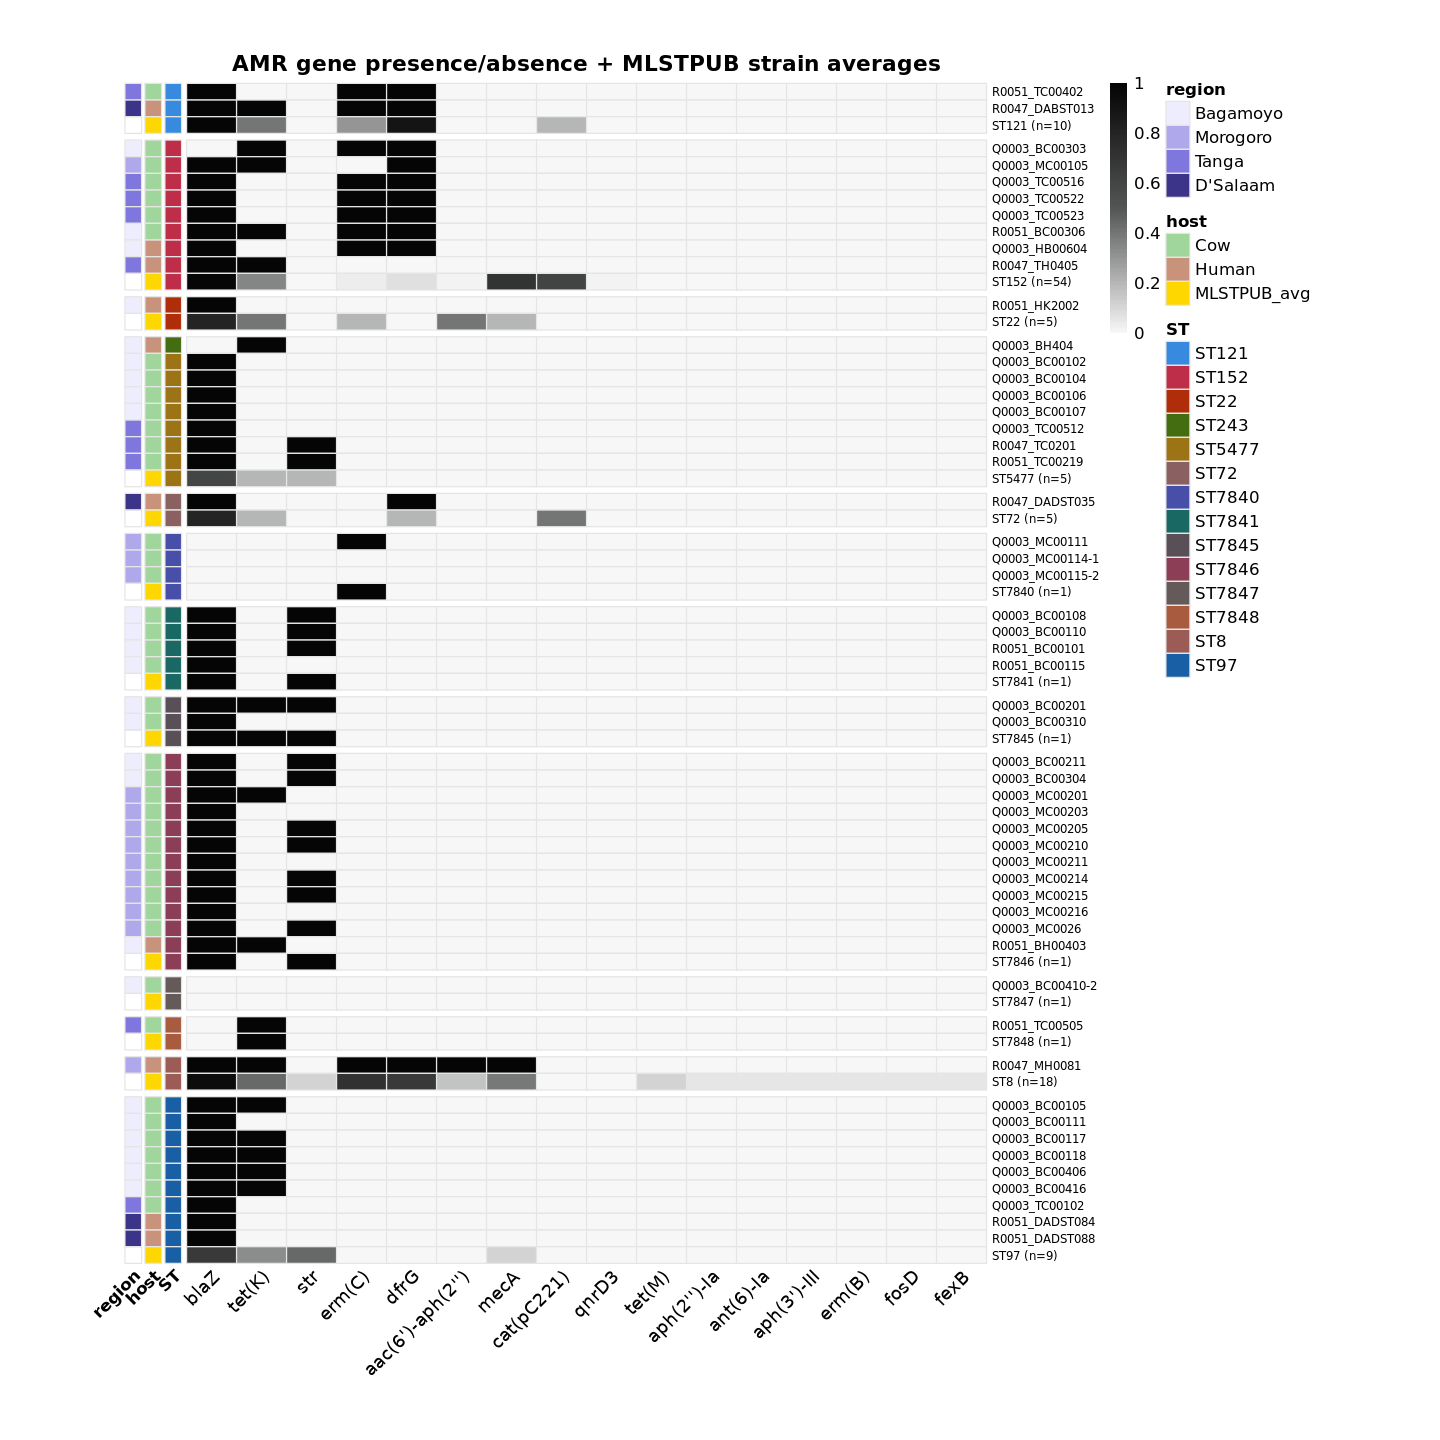

In [29]:
options(repr.plot.width = 12, repr.plot.height = 12)

# Update ST levels and colors to include MLSTPUB_avg rows
st_levels_combined <- unique(annot_row_combined$ST) |> sort()
st_cols_combined <- setNames(
  colorRampPalette(c("#378ADD","#fa0606","#3B6D11","#BA7517",
                     "#534AB7","#0F6E56","#993556","#5F5E5A",
                     "#D85A30","#185FA5"))(length(st_levels_combined)),
  st_levels_combined
)

ann_colors_combined <- ann_colors
ann_colors_combined$ST <- st_cols_combined
ann_colors_combined$host <- c(ann_colors$host, "MLSTPUB_avg" = "#FFD700")

# Get sample and average row names
sample_rows <- rownames(pa_mat)
avg_rows    <- rownames(pa_strain_avg)  # now named like "ST97 (n=42)"

# Extract ST for each sample
sample_ST <- annot_row[sample_rows, "ST"]

# avg_ST: strip the "(n=...)" suffix to match original ST labels
avg_ST_key <- setNames(
  str_extract(avg_rows, "^ST[0-9]+"),
  avg_rows
)

# Build new order: samples for each ST, then its avg row
new_order <- c()
for (st in unique(sample_ST)) {
  these_samples <- sample_rows[sample_ST == st]
  new_order <- c(new_order, these_samples)
  matching_avg <- names(avg_ST_key)[avg_ST_key == st]
  if (length(matching_avg) > 0) {
    new_order <- c(new_order, matching_avg)
  }
}

# Reorder
pa_combined <- pa_combined[new_order, , drop=FALSE]
pa_combined[] <- lapply(pa_combined, as.numeric)
pa_combined <- as.matrix(pa_combined)

annot_row_combined <- annot_row_combined[new_order, , drop=FALSE]

# Gaps AFTER each avg row (= end of each strain block)
gap_pos_combined <- which(annot_row_combined$host == "MLSTPUB_avg")
gap_pos_combined <- gap_pos_combined[gap_pos_combined < nrow(annot_row_combined)]

# Plot
pheatmap(
  pa_combined,
  annotation_row    = annot_row_combined,
  annotation_colors = ann_colors_combined,
  cluster_rows      = FALSE,
  cluster_cols      = FALSE,
  gaps_row          = gap_pos_combined,
  color             = colorRampPalette(c("#F7F7F7", "#545555", "#050505"))(101),
  breaks            = seq(0, 1, length.out = 102),
  border_color      = "grey90",
  cellwidth         = 30,
  cellheight        = 10,
  fontsize_row      = 7,
  fontsize_col      = 11,
  angle_col         = 45,
  legend            = TRUE,
  main              = "AMR gene presence/absence + MLSTPUB strain averages",
  width             = 14,
  height            = 18
)

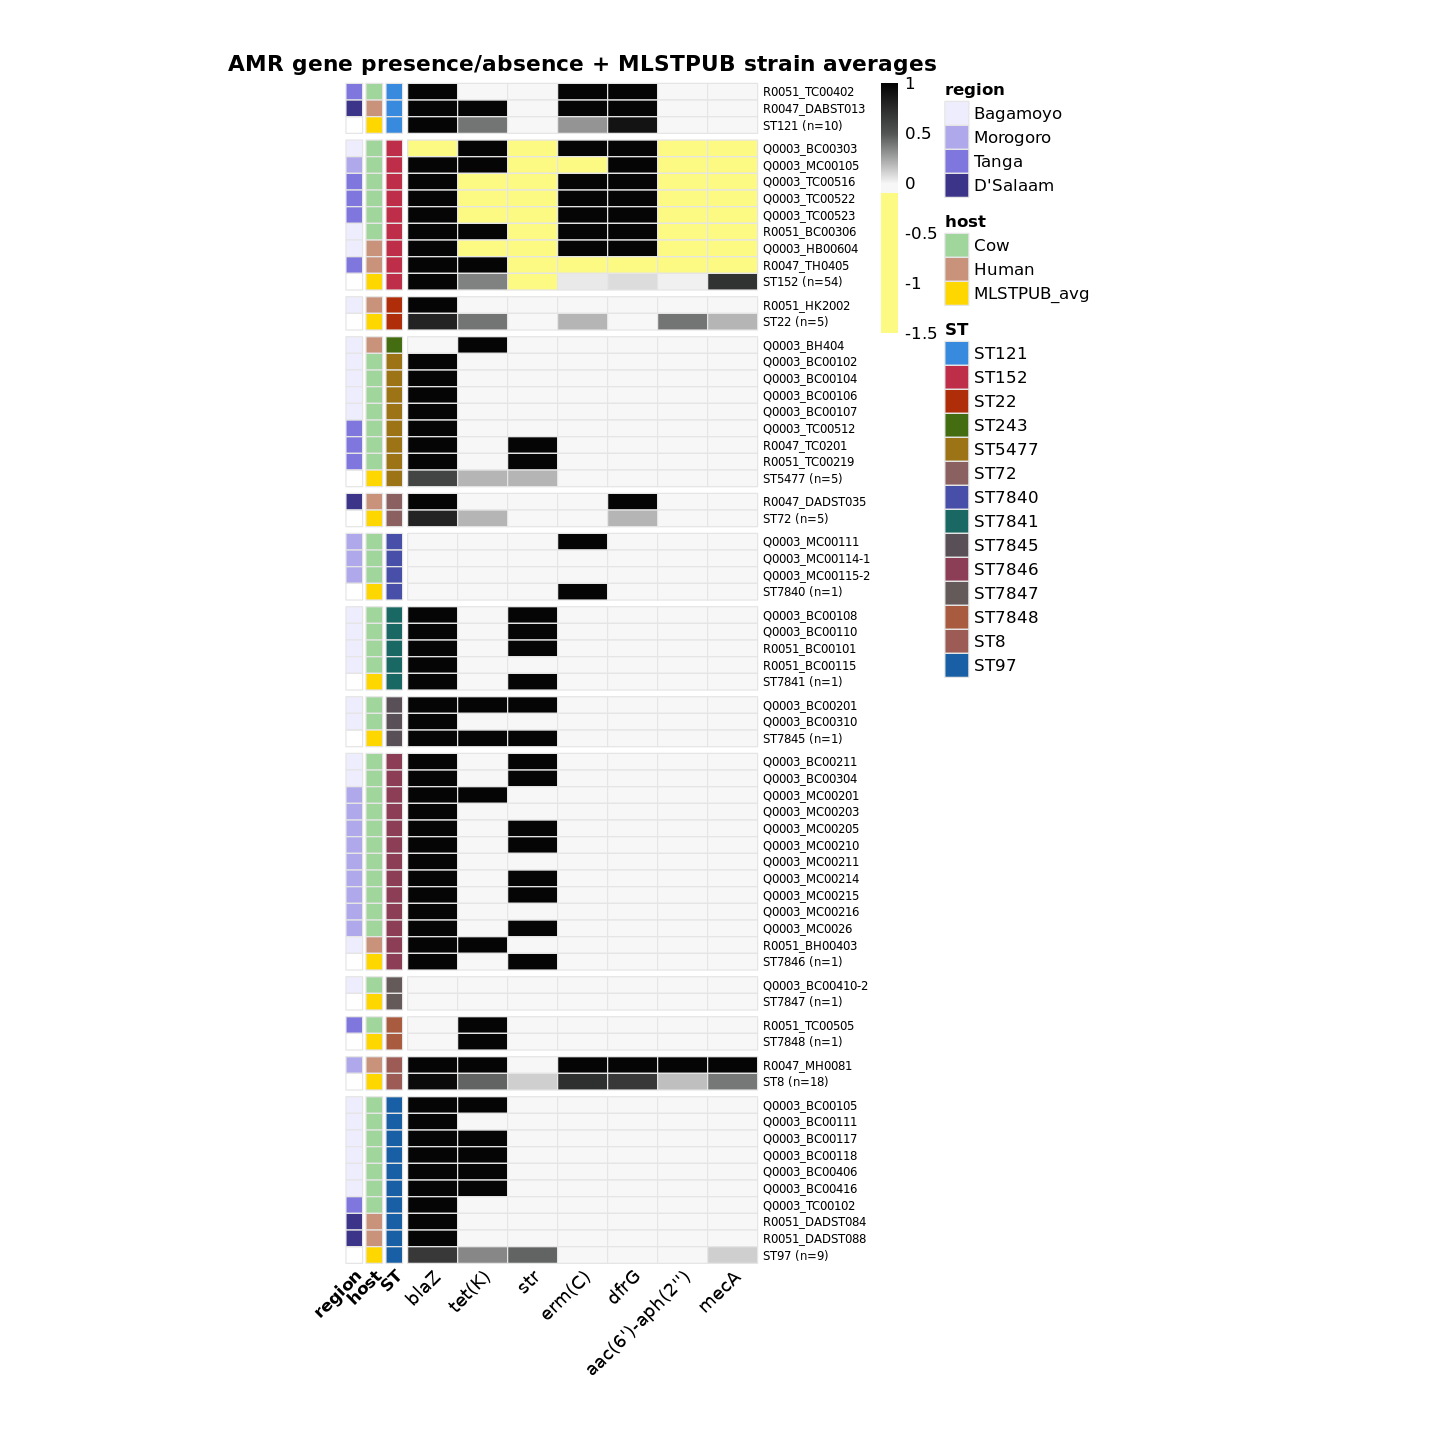

In [30]:
our_genes <- colnames(pa_mat_our)
# subset to only genes present in our Tanzania data
pa_combined_subset <- pa_combined[, our_genes, drop = FALSE]

# make ST152 emoty cells light yellow
pa_highlighted <- pa_combined_subset
st152_rows <- rownames(annot_row_combined)[annot_row_combined$ST == "ST152"]

tmp <- pa_highlighted[st152_rows, , drop = FALSE]
tmp[tmp == 0] <- -1
pa_highlighted[st152_rows, ] <- tmp

pheatmap(
  pa_highlighted,
  annotation_row    = annot_row_combined,
  annotation_colors = ann_colors_combined,
  cluster_rows      = FALSE,
  cluster_cols      = FALSE,
  gaps_row          = gap_pos_combined,
  color             = c("#fcfa83", colorRampPalette(c("#F7F7F7", "#545555", "#050505"))(100)), # yellow, then white-black gradient
  breaks            = c(-1.5, -0.1, seq(0, 1, length.out = 101)), # -1, then 0 to 1
  border_color      = "grey90",
  cellwidth         = 30,
  cellheight        = 10,
  fontsize_row      = 7,
  fontsize_col      = 11,
  angle_col         = 45,
  legend            = TRUE,
  main              = "AMR gene presence/absence + MLSTPUB strain averages",
  width             = 14,
  height            = 18,
  silent            = FALSE
)

Metadata !!

In [31]:
mlstpub_meta <- read_tsv("../../results_for_analysis/metadata/africa_target_sts_with_genomes.tsv")
head(mlstpub_meta)

Rows: 130 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (8): isolate, country, continent, region, sex, disease, source_category...
dbl (10): id, year, arcC, aroE, glpF, gmk, pta, tpi, yqiL, ST (MLST)

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


id,isolate,country,continent,region,year,sex,disease,source_category,source,arcC,aroE,glpF,gmk,pta,tpi,yqiL,ST (MLST)
<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7459,ERR017301,Namibia,Africa,NA,2009,NA,unknown,unknown,unknown,7,6,1,5,8,8,6,22
7529,ERR017291,Namibia,Africa,NA,2009,NA,unknown,unknown,unknown,7,6,1,5,8,8,6,22
7684,ERR017256,Nigeria,Africa,NA,2002,NA,unknown,unknown,unknown,7,6,1,5,8,8,6,22
7735,ERR017257,Sudan,Africa,NA,2007,NA,unknown,unknown,unknown,7,6,1,5,8,8,6,22
21212,ERR227490,Algeria,Africa,NA,2005,NA,unknown,unknown,unknown,3,1,1,1,1,5,3,97
24326,ERR505358,Tanzania,Africa,NA,2013,NA,unknown,unknown,unknown,3,3,1,1,4,4,3,8


In [32]:
colnames(mlstpub_meta)

[1] "id"              "isolate"         "country"         "continent"      
 [5] "region"          "year"            "sex"             "disease"        
 [9] "source_category" "source"          "arcC"            "aroE"           
[13] "glpF"            "gmk"             "pta"             "tpi"            
[17] "yqiL"            "ST (MLST)"

In [33]:
annot_row_152 <- annot_row |> 
    filter(ST == "ST152") |>
    mutate(host = tolower(host),
        country = "Tanzania") |>
    select(host, country)

annot_row_152

,host,country
,<chr>,<chr>
Q0003_BC00303,cow,Tanzania
Q0003_MC00105,cow,Tanzania
Q0003_TC00516,cow,Tanzania
Q0003_TC00522,cow,Tanzania
Q0003_TC00523,cow,Tanzania
R0051_BC00306,cow,Tanzania
Q0003_HB00604,human,Tanzania
R0047_TH0405,human,Tanzania


In [34]:
# get annotation
mlstpub_annot_152 <- mlstpub_meta |>
    filter(`ST (MLST)` == 152) |>
    select(id, country, source_category) |> 
    mutate(
        id = as.character(id),
        host = source_category
    ) |>
    select(-source_category) |>
    column_to_rownames("id")

# extract id from passed_samples_aug
passed_ids <- passed_samples_aug$X1 |>
  str_extract("id(\\d+)") |>
  str_remove("^id")

# filter mlstpub_annot_152 to only keep samples in passed_ids
mlstpub_annot_152 <- mlstpub_annot_152 |>
  filter(rownames(mlstpub_annot_152) %in% passed_ids)
  
head(mlstpub_annot_152)

annot_st152 <- bind_rows(annot_row_152, mlstpub_annot_152)


,country,host
,<chr>,<chr>
37087,Rwanda,food
37092,Rwanda,food
37093,Rwanda,food
37104,Rwanda,food
37105,Rwanda,food
37109,Rwanda,food


In [35]:
# extract strain 152
pa_mat_aug_st152 <- pa_mat_aug[str_detect(rownames(pa_mat_aug), "^ST152"), , drop = FALSE]
#pa_mat_aug_st152 <- pa_mat_aug_st152[, our_genes, drop = FALSE]

# fix ids
# extract numeric id from row names
rownames(pa_mat_aug_st152) <- str_match(rownames(pa_mat_aug_st152), "id(\\d+)")[, 2]


# ids to pull from pa_mat
our_ids_152 <- rownames(annot_row_152)

# take those rows from pa_mat
pa_mat_our_st152 <- pa_mat[our_ids_152, , drop = FALSE]

# make sure both matrices have the same columns
all_genes_152 <- union(colnames(pa_mat_our_st152), colnames(pa_mat_aug_st152))

for (gene in setdiff(all_genes_152, colnames(pa_mat_our_st152))) {
  pa_mat_our_st152 <- cbind(pa_mat_our_st152, setNames(data.frame(rep(0, nrow(pa_mat_our_st152))), gene))
}

for (gene in setdiff(all_genes_152, colnames(pa_mat_aug_st152))) {
  pa_mat_aug_st152 <- cbind(pa_mat_aug_st152, setNames(data.frame(rep(0, nrow(pa_mat_aug_st152))), gene))
}

pa_mat_our_st152  <- pa_mat_our_st152[, all_genes_152, drop = FALSE]
pa_mat_aug_st152  <- pa_mat_aug_st152[, all_genes_152, drop = FALSE]

# combine
pa_mat_st152 <- rbind(pa_mat_our_st152, pa_mat_aug_st152)
#pa_mat_st152 <- pa_mat_st152[, our_genes, drop = FALSE]


# sort by country first
annot_st152 <- annot_st152 |>
  arrange(country, host)

annot_st152 <- annot_st152 |>
  slice(rev(row_number()))

# match matrix order
pa_mat_st152 <- pa_mat_st152[rownames(annot_st152), , drop = FALSE]
# remove columns that are entirely 0
pa_mat_st152 <- pa_mat_st152[, colSums(pa_mat_st152) > 0, drop = FALSE]

# gaps between countries
gap_pos_country <- annot_st152 |>
  mutate(row_n = row_number()) |>
  group_by(country) |>
  summarise(last = max(row_n), .groups = "drop") |>
  arrange(last) |>
  pull(last) |>
  head(-1)


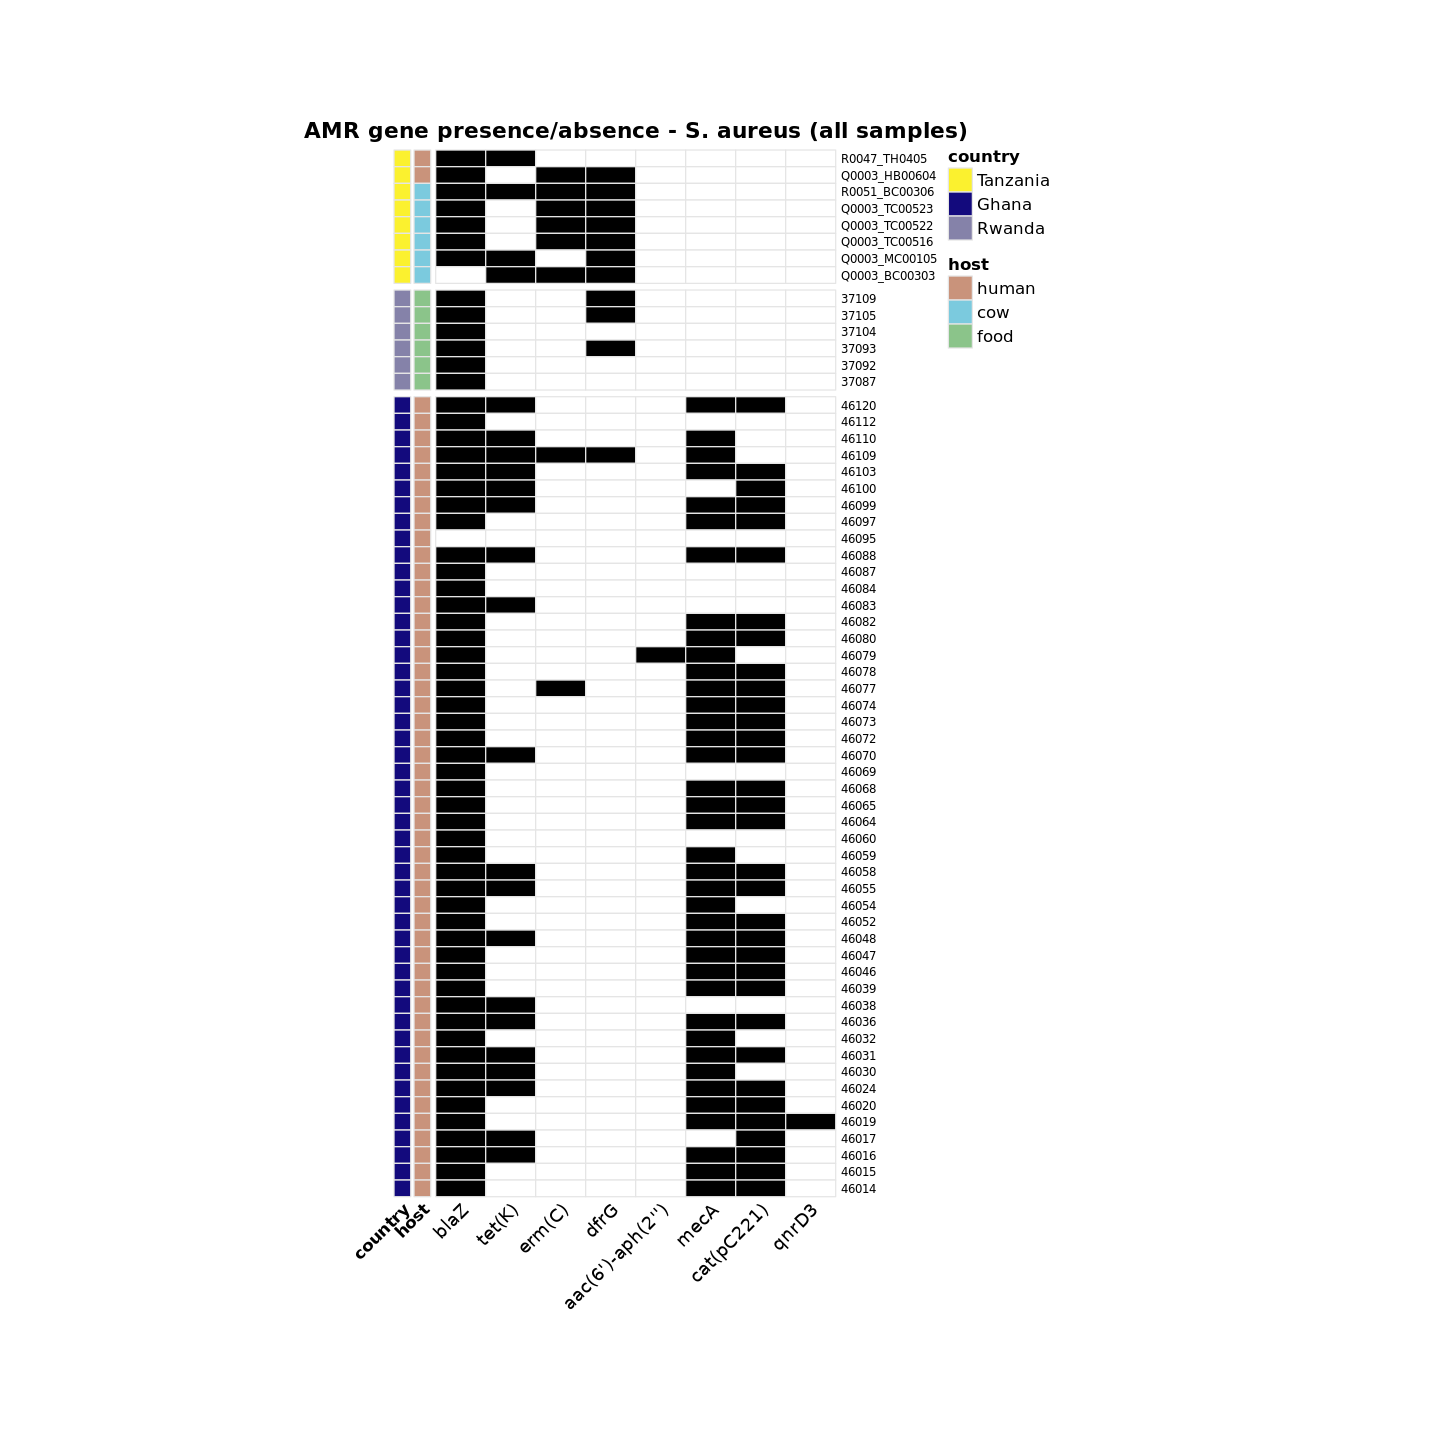

In [36]:
ann_colors <- list(
  country = c(
    "Tanzania" = "#fbf12f",
    "Ghana"    = "#130a7d",
    "Rwanda"   = "#8582a9"
  ),
  host = c(
    "human" = "#c9937b",
    "cow"   = "#7bcade",
    "food"  = "#8bc48a"
  )
)

pheatmap(
  pa_mat_st152,
  annotation_row    = annot_st152,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = FALSE,
  gaps_row          = gap_pos_country,
  color             = c("white", "black"),
  breaks            = c(-0.5, 0.5, 1.5),
  border_color      = "grey90",
  cellwidth         = 30,
  cellheight        = 10,
  fontsize_row      = 7,
  fontsize_col      = 11,
  angle_col         = 45,
  legend            = FALSE,
  main              = "AMR gene presence/absence - S. aureus (all samples)",
  #          = "results/resfinder_heatmap.pdf",
  width             = 14,
  height            = 18
)